# Задача сегментации с использованием U-Net

In [ ]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from tqdm import tqdm

import albumentations as A
from albumentations.core.composition import Compose
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score
import glob
import tensorflow as tf
from tensorflow.keras import models, layers, Sequential
from tensorflow.keras.layers import Flatten, Dense, Reshape
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import img_to_array, load_img

In [ ]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!nvidia-smi

Thu Oct 16 07:21:06 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             32W /   70W |     144MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Simple test
with tf.device('/GPU:0'):
    a = tf.random.normal([1000, 1000])
    b = tf.random.normal([1000, 1000])
    c = tf.matmul(a, b)
print("Computation done on GPU")


Computation done on GPU


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vpapenko/nails-segmentation")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'nails-segmentation' dataset.
Path to dataset files: /kaggle/input/nails-segmentation


## Функции для отображения результатов

In [ ]:
def plot_image_and_mask(images, masks, num_samples=5):
    plt.figure(figsize=(20, 6))

    for i in range(num_samples):
        idx = np.random.randint(len(images))

        # изображение
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(images[idx], cmap='gray' if images.shape[-1] == 1 else None)
        plt.axis("off")
        plt.title(f"Image {idx}")

        # маска
        plt.subplot(2, num_samples, i + 1 + num_samples)
        plt.imshow(masks[idx].squeeze(), cmap='gray')
        plt.axis("off")
        plt.title("Mask")

    plt.tight_layout()
    plt.show()


In [ ]:
def plot_predictions(X_test, y_test, preds):
    plt.figure(figsize=(20, 6))

    for i in range(6):
        idx = np.random.randint(len(preds))
        plt.subplot(3, 8, i + 1)
        plt.imshow(X_test[idx], cmap="gray")
        plt.axis("off")
        plt.title("Image")

        plt.subplot(3, 8, i + 9)
        plt.imshow(y_test[idx], cmap="gray")
        plt.axis("off")
        plt.title("Original Mask")

        plt.subplot(3, 8, i + 17)
        plt.imshow(preds[idx], cmap="gray")
        plt.axis("off")
        plt.title("Predicted Mask")

    plt.show()

In [ ]:
def plot_training_history(history, title="Training History"):
    metrics = [m for m in history.history.keys() if not m.startswith('val_')]
    n_metrics = len(metrics)

    n_cols = 2
    n_rows = (n_metrics + 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten()
    fig.suptitle(title, fontsize=16)

    for i, metric in enumerate(metrics):
        ax = axes[i]
        ax.plot(history.history[metric], label=f"train {metric}")

        val_metric = f"val_{metric}"
        if val_metric in history.history:
            ax.plot(history.history[val_metric], label=f"val {metric}")

        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric.capitalize())
        ax.set_title(f"Training vs Validation {metric.capitalize()}")
        ax.legend()
        ax.grid(True)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


## Подготовка данных

In [ ]:
folders = os.listdir(path)
folders

['labels', 'nails_segmentation', 'images']

In [ ]:
image_paths = glob.glob(path+'/images/*')
mask_paths = glob.glob(path+'/labels/*')

In [ ]:
def load_image(path, color_mode=None):
    img = None
    if color_mode:
        img = load_img(path, target_size=(128, 128), color_mode=color_mode)
    else:
        img = load_img(path, target_size=(128, 128))

    image_array = img_to_array(img)
    image_array /= 255.
    return image_array

In [ ]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(p=0.2)
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
images = []
masks = []

for image_path, mask_path in tqdm(zip(image_paths, mask_paths)):
    image = load_image(image_path)
    images.append(image)

    mask = load_image(mask_path, color_mode='grayscale')
    masks.append(mask)

    augmented = transform(image=image, mask=mask)
    image_aug = augmented['image']
    mask_aug = augmented['mask']

    images.append(image_aug)
    masks.append(mask_aug)

52it [00:01, 35.09it/s]


In [ ]:
images = np.array(images)
masks = np.array(masks)

In [ ]:
masks.shape

(104, 128, 128, 1)

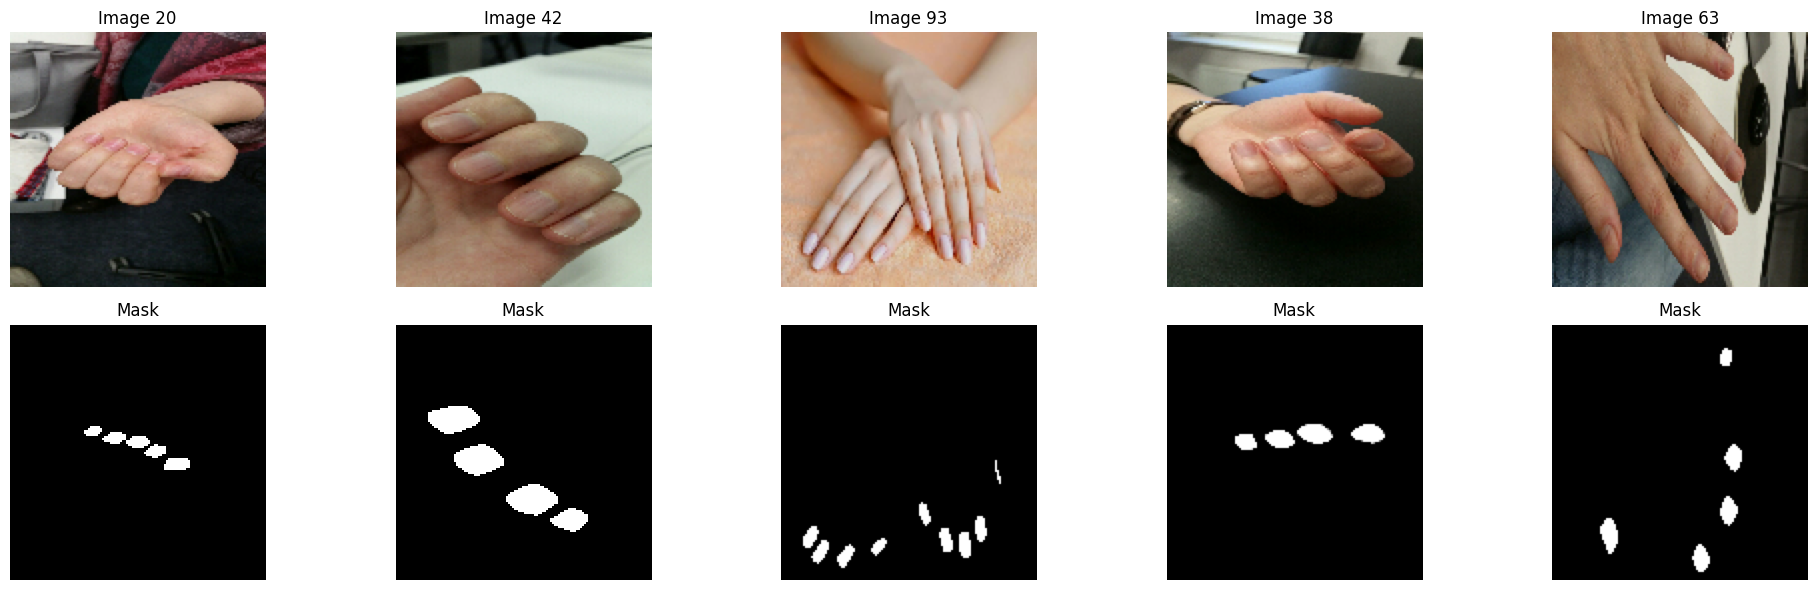

In [ ]:
plot_image_and_mask(images, masks)

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(images, masks, test_size=0.2, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Valid set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Train set: (83, 128, 128, 3), (83, 128, 128, 1)
Valid set: (10, 128, 128, 3), (10, 128, 128, 1)
Test set: (11, 128, 128, 3), (11, 128, 128, 1)


## Baseline - Полносвязанная нейронная сеть

In [ ]:
input_shape = (128, 128, 3)
output_shape = (128, 128, 1)

sequential_model = Sequential([
    Flatten(input_shape=input_shape),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(np.prod(output_shape), activation='sigmoid'),
    Reshape(output_shape)
])

sequential_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)
# sequential_model.summary()

In [ ]:
sequential_history = sequential_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5685 - loss: 0.6604 - precision_1: 0.0536 - recall_1: 0.4301 - val_accuracy: 0.8887 - val_loss: 0.3126 - val_precision_1: 0.0329 - val_recall_1: 0.0934
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8955 - loss: 0.3337 - precision_1: 0.0524 - recall_1: 0.0603 - val_accuracy: 0.9679 - val_loss: 0.1581 - val_precision_1: 0.0561 - val_recall_1: 0.0034
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9467 - loss: 0.2179 - precision_1: 0.1005 - recall_1: 0.0029 - val_accuracy: 0.9688 - val_loss: 0.1516 - val_precision_1: 0.0429 - val_recall_1: 0.0012
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9491 - loss: 0.2018 - precision_1: 0.1781 - recall_1: 0.0029 - val_accuracy: 0.9691 - val_loss: 0.1654 - val_precision_1: 0.0568 - val_recall_1: 0.0010
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9470 - loss: 0.2040 - precision_1: 0.1956 - recall_1: 0.0015 - val_accurac

## Реализация U-Net

In [ ]:
def conv_block(inputs, num_filters):
    x = layers.Conv2D(num_filters, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    x = layers.Conv2D(num_filters, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(x)
    return x


In [ ]:
def encoder_block(inputs, num_filters):
    x = conv_block(inputs, num_filters)
    p = layers.MaxPooling2D((2, 2))(x)
    return x, p


In [ ]:
def decoder_block(inputs, skip_features, num_filters):
    x = layers.Conv2DTranspose(num_filters, (2, 2), strides=(2, 2), padding='same')(inputs)
    x = layers.concatenate([x, skip_features])
    x = conv_block(x, num_filters)
    return x

In [ ]:
def build_unet(input_shape=(128, 128, 3), num_classes=1):
    inputs = layers.Input(shape=input_shape)

    # --- Encoder ---
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # --- Bottleneck ---
    b1 = conv_block(p4, 1024)

    # --- Decoder ---
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    # --- Output ---
    outputs = layers.Conv2D(num_classes, (1, 1), activation='sigmoid')(d4)

    model = models.Model(inputs, outputs, name="U-Net")

    return model

In [ ]:
unet_model = build_unet(input_shape=(128, 128, 3), num_classes=1)
unet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)
# unet_model.summary()

In [ ]:
unet_history = unet_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=300)

Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 62s 25s/step - accuracy: 0.9420 - loss: 0.4998 - precision_3: 0.0030 - recall_3: 3.2972e-04 - val_accuracy: 0.9695 - val_loss: 0.2447 - val_precision_3: 0.0000e+00 - val_recall_3: 0.0000e+00
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 381ms/step - accuracy: 0.9483 - loss: 0.3259 - precision_3: 0.0000e+00 - recall_3: 0.0000e+00 - val_accuracy: 0.9695 - val_loss: 0.2350 - val_precision_3: 0.0000e+00 - val_recall_3: 0.0000e+00
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 378ms/step - accuracy: 0.9488 - loss: 0.3071 - precision_3: 0.0000e+00 - recall_3: 0.0000e+00 - val_accuracy: 0.9695 - val_loss: 0.2633 - val_precision_3: 0.0000e+00 - val_recall_3: 0.0000e+00
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 380ms/step - accuracy: 0.9495 - loss: 0.3546 - precision_3: 0.0000e+00 - recall_3: 0.0000e+00 - val_accuracy: 0.9695 - val_loss: 0.2548 - val_precision_3: 0.0000e+00 - val_recall_3: 0.0000e+00
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 375ms/step - accuracy: 0.9473 - l

## Сравнение результатов

### Baseline

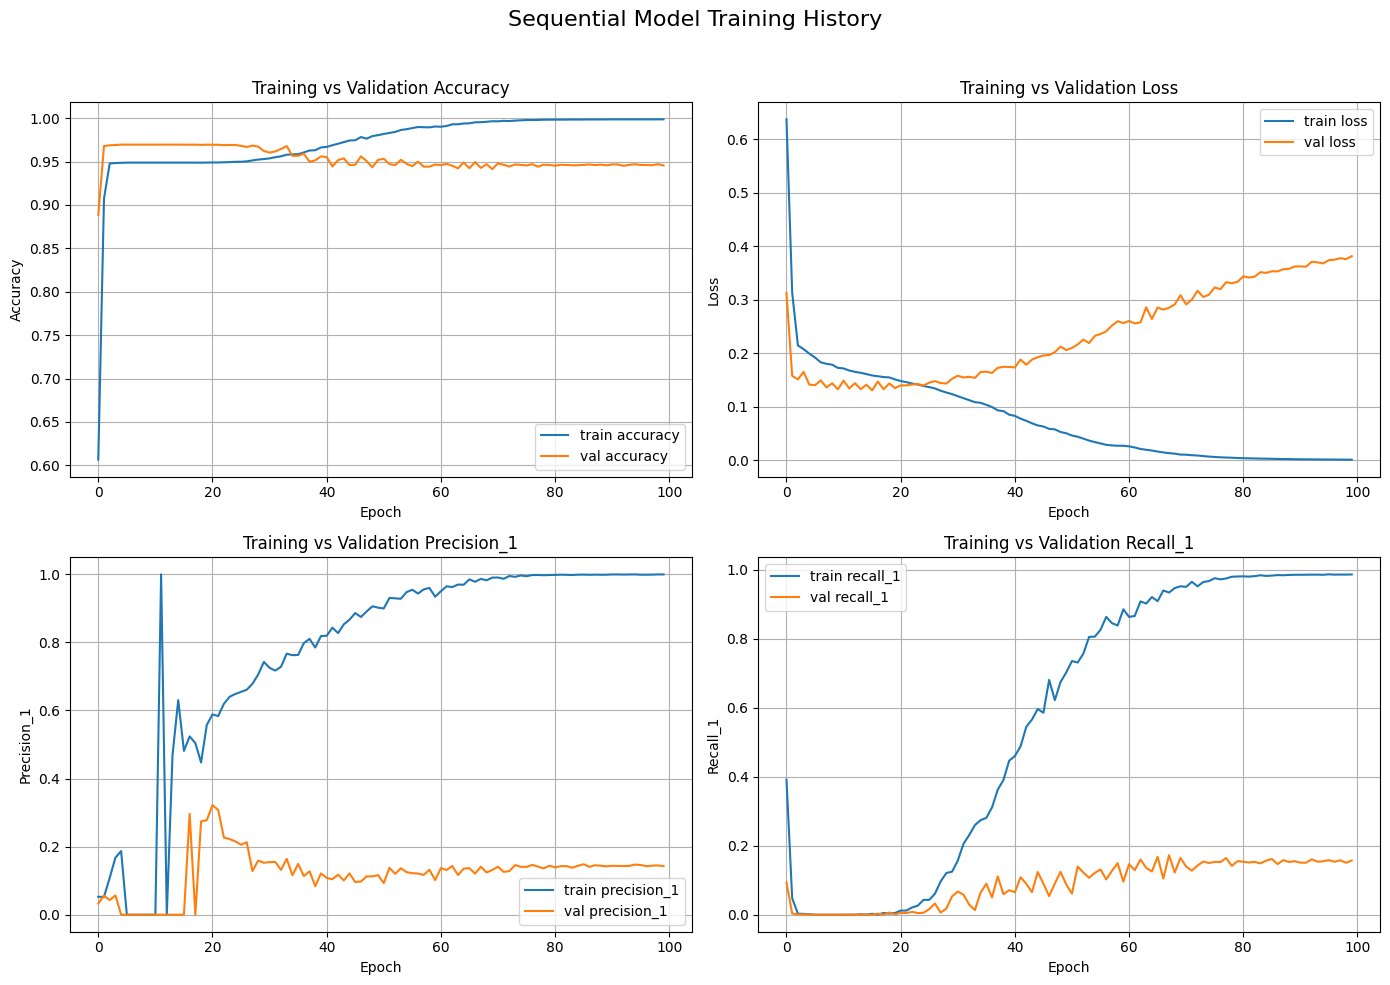

In [ ]:
plot_training_history(sequential_history, title = "Sequential Model Training History")

In [ ]:
seq_y_pred = sequential_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step


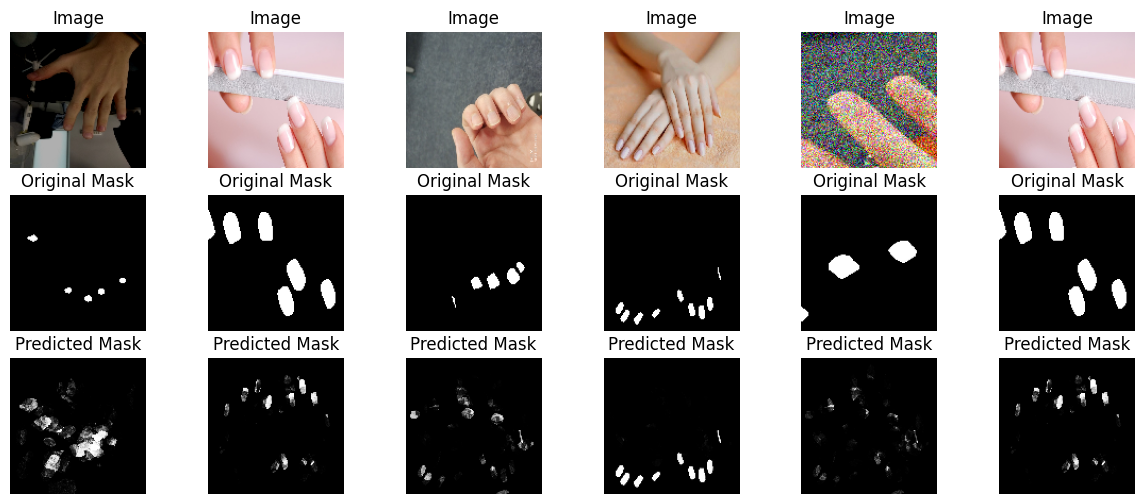

In [ ]:
plot_predictions(X_test, y_test, seq_y_pred)

In [ ]:
seq_results = sequential_model.evaluate(X_test, y_test, verbose=0)
metrics_names = sequential_model.metrics_names
for name, value in zip(metrics_names, seq_results):
    print(f"{name}: {value:.4f}")

loss: 0.5079
compile_metrics: 0.9410


### U-Net

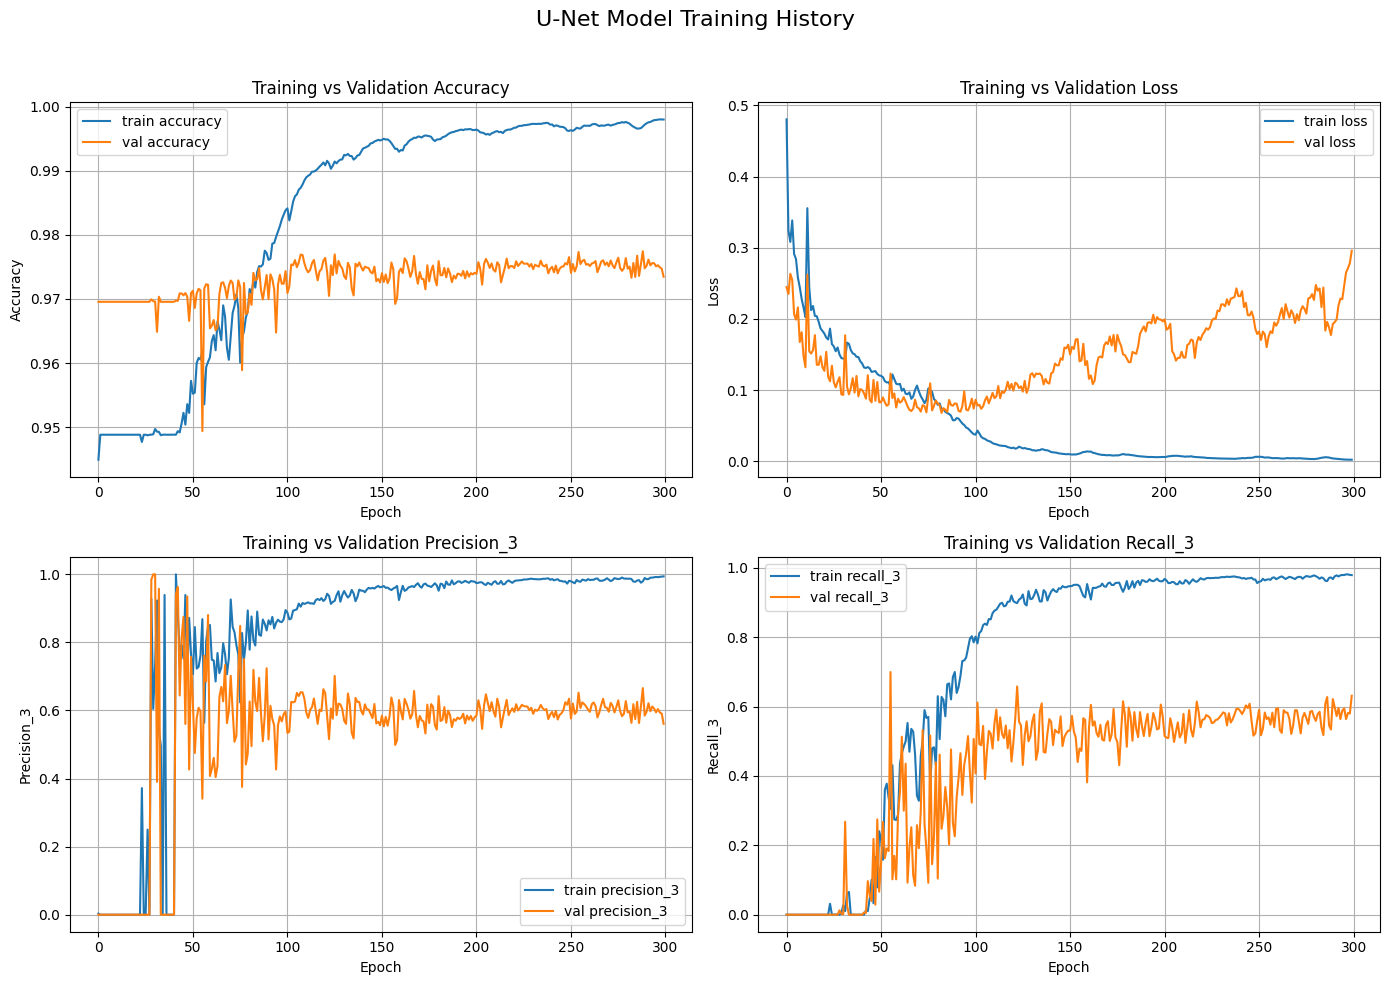

In [ ]:
plot_training_history(unet_history, title = "U-Net Model Training History")

In [ ]:
unet_y_pred = unet_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


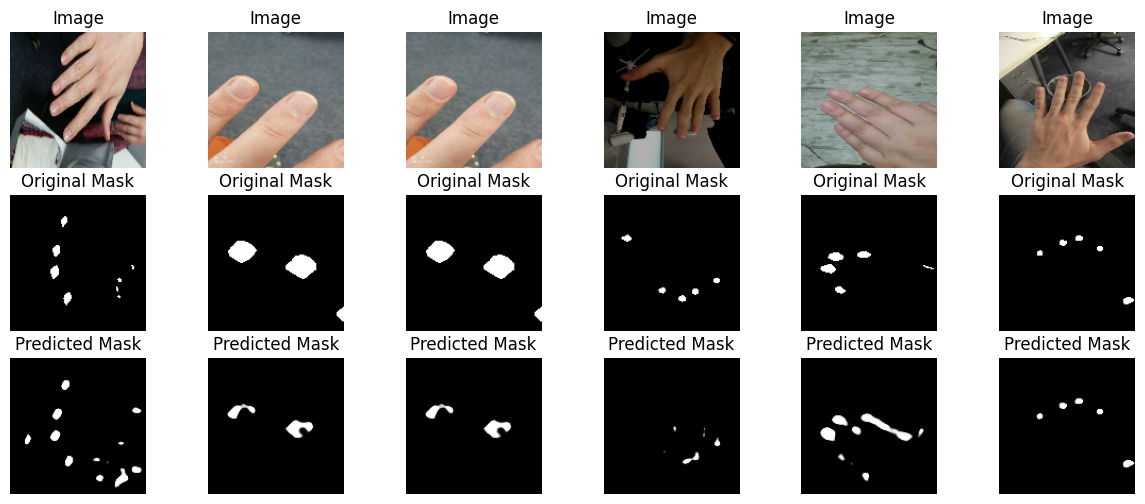

In [ ]:
plot_predictions(X_test, y_test, unet_y_pred)

In [ ]:
unet_results = unet_model.evaluate(X_test, y_test, verbose=0)
metrics_names = unet_model.metrics_names
for name, value in zip(metrics_names, unet_results):
    print(f"{name}: {value:.4f}")

loss: 0.3221
compile_metrics: 0.9709
